# Two-Step QAOA: Improved Stage-1 Loss for Dicke State Approximation

## Overview

This notebook extends the benchmark from `expanded_benchmark.ipynb` by introducing two new methods:

| Method | Description |
|--------|-------------|
| **Baseline** | X-mixer + constraint cost `⟨(N̂-k)²⟩`, random restarts (COBYLA) |
| **M1: INTERP** | Layer-by-layer growth; INTERP warm-start |
| **M4: Combo** | M1 + augmented cost with fixed α=2 variance penalty |
| **M5: Adaptive-α** | M4 + cosine-annealed α + L-BFGS-B polish |
| **M6: Subspace Projector Loss** | *(New)* Minimizes `1 - ‖P_k |ψ⟩‖²` — directly maximizes probability mass in the k-hot subspace |
| **M7: Subspace + Uniformity** | *(New)* M6 loss + entropy penalty to enforce uniform amplitude across k-hot bitstrings (exact Dicke = max entropy in subspace) |

### Why the existing losses are insufficient

The current Stage-1 loss `⟨(N̂-k)²⟩ + α·Var(N̂)` is **necessary but not sufficient** to approximate a Dicke state:
- A state with all amplitude on a **single** k-hot bitstring satisfies `⟨(N̂-k)²⟩ = 0` and `Var(N̂) = 0`
- But its fidelity with the Dicke state `|D(n,k)⟩ = 1/√C(n,k) Σ|x⟩` is only `1/C(n,k)` — tiny!
- The Dicke state requires **uniform** amplitude across all C(n,k) bitstrings in the subspace

**M6** fixes the first issue: it directly maximizes `‖P_k|ψ⟩‖²` — total probability in the k-hot subspace.

**M7** fixes both issues: it also penalizes non-uniformity within the subspace using a negative-entropy term.

$$\mathcal{L}_{M7} = \underbrace{(1 - \|P_k|\psi\rangle\|^2)}_{\text{subspace projection}} + \beta \underbrace{\sum_{x: |x|=k} p_x \log(C(n,k)\cdot p_x)}_{\text{KL divergence from uniform}}$$

The second term is the KL divergence of the amplitude distribution within the k-hot subspace from the uniform distribution. It is zero iff `|ψ⟩` restricted to the subspace is the exact Dicke state.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from itertools import combinations
from functools import reduce
from scipy.optimize import minimize
from math import comb, sqrt, log
import time, warnings
warnings.filterwarnings('ignore')

I2 = np.eye(2, dtype=complex)
X  = np.array([[0,1],[1,0]],    dtype=complex)
Y  = np.array([[0,-1j],[1j,0]], dtype=complex)
Z  = np.array([[1,0],[0,-1]],   dtype=complex)

def single_op(n, i, op):
    ops = [I2]*n; ops[i] = op
    return reduce(np.kron, ops)

np.set_printoptions(precision=4, suppress=True)
print("Imports OK")

Imports OK


## Core Helpers (unchanged from original)

In [2]:
def exact_dicke(n, k):
    sv   = np.zeros(2**n, dtype=complex)
    norm = 1.0 / sqrt(comb(n, k))
    for bits in combinations(range(n), k):
        sv[sum(1 << b for b in bits)] = norm
    return sv

def hamming_weight_arr(n):
    return np.array([bin(i).count('1') for i in range(2**n)], dtype=float)

def constraint_diag(n, k):
    """Diagonal of H_C = (sum_i n_i - k)^2."""
    return (hamming_weight_arr(n) - k) ** 2

def x_mixer_eig(n):
    H = sum(single_op(n, i, X) for i in range(n)).real
    return np.linalg.eigh(H)

def run_qaoa(n, c_diag, eig, evec, p, params, init=None):
    s = (np.ones(2**n, dtype=complex) / np.sqrt(2**n)
         if init is None else init.copy())
    for l in range(p):
        s = np.exp(-1j * params[l]       * c_diag) * s
        s = evec @ (np.exp(-1j * params[p + l] * eig) * (evec.conj().T @ s))
    return s

def interp_schedule(params_old, p_new):
    p_old = len(params_old) // 2
    def interp(arr, pn):
        out = np.zeros(pn)
        for i in range(1, pn + 1):
            frac  = (i - 1) / (pn - 1) if pn > 1 else 0.0
            jc    = frac * (p_old - 1)
            j0    = int(jc); j1 = min(j0 + 1, p_old - 1)
            out[i-1] = (1 - (jc - j0)) * arr[j0] + (jc - j0) * arr[j1]
        return out
    return np.concatenate([interp(params_old[:p_old], p_new),
                            interp(params_old[p_old:], p_new)])

print("Core helpers defined.")

Core helpers defined.


## New: Subspace Projection Helpers

These build the machinery for M6 and M7.

In [3]:
# ── Precompute k-hot subspace indices ─────────────────────────────────────────
_khot_cache = {}
def khot_indices(n, k):
    """Sorted array of basis indices with exactly k ones."""
    if (n, k) not in _khot_cache:
        _khot_cache[(n, k)] = np.array(
            [sum(1 << b for b in bits) for bits in combinations(range(n), k)],
            dtype=int)
    return _khot_cache[(n, k)]


def subspace_projection_loss(s, n, k):
    """
    M6 loss: 1 - ||P_k |psi>||^2
    = 1 - (total probability in the k-hot subspace)
    Zero iff state is entirely in the k-hot subspace.
    """
    idx = khot_indices(n, k)
    return 1.0 - float(np.sum(np.abs(s[idx])**2))


def subspace_uniformity_loss(s, n, k, beta=1.0, eps=1e-12):
    """
    M7 loss: subspace_projection_loss + beta * KL(q || uniform)

    Where q is the conditional distribution of the state within the k-hot
    subspace.  KL divergence from the uniform distribution over C(n,k) states
    is zero iff q is exactly uniform — i.e., the state is a Dicke state.

    KL(q||u) = sum_x q_x * log(C(n,k) * q_x)
             = log(C(n,k)) + sum_x q_x * log(q_x)   (= log(C) - H(q))

    This formulation makes the combined loss:
       L = (1 - ||P_k psi||^2)  +  beta * KL(q||uniform)
    """
    idx    = khot_indices(n, k)
    probs  = np.abs(s[idx])**2
    P_sub  = probs.sum()                       # total mass in subspace
    proj   = 1.0 - P_sub                       # subspace projection loss

    if P_sub < eps:
        return proj + beta * log(comb(n, k))   # max KL when no mass in subspace

    q    = probs / P_sub                       # conditional distribution in subspace
    q    = np.maximum(q, eps)                  # numerical stability
    kl   = float(np.sum(q * np.log(comb(n, k) * q)))  # KL from uniform
    return proj + beta * kl


# Quick sanity: exact Dicke state should give 0 loss for both
for n_t, k_t in [(4, 2), (5, 2), (6, 3)]:
    d = exact_dicke(n_t, k_t)
    l6 = subspace_projection_loss(d, n_t, k_t)
    l7 = subspace_uniformity_loss(d, n_t, k_t)
    print(f"|D^{n_t}_{k_t}>  M6 loss={l6:.2e}  M7 loss={l7:.2e}  (should be ~0)")

|D^4_2>  M6 loss=-2.22e-16  M7 loss=-2.22e-16  (should be ~0)
|D^5_2>  M6 loss=0.00e+00  M7 loss=0.00e+00  (should be ~0)
|D^6_3>  M6 loss=0.00e+00  M7 loss=-1.11e-16  (should be ~0)


## M6 — Subspace Projector Loss

In [4]:
def m6_projector(n, k, p_max, n_boot=12, seed=0):
    """
    M6: Direct subspace projection loss.

    Loss = 1 - ||P_k |psi(gamma,beta)||^2

    This is strictly better-posed than constraint energy:
    - The minimum (loss=0) is achieved iff the state lives entirely in the
      k-hot subspace, which is a necessary condition for a Dicke state.
    - No penalty-weight tuning needed (no alpha).
    - Gradient landscape is smoother: the loss is a sum of squared amplitudes,
      not a quadratic expectation value.

    Uses: INTERP warm-start (same as M1..M5) + L-BFGS-B polish.
    """
    np.random.seed(seed)
    cd        = constraint_diag(n, k).astype(complex)
    eig, evec = x_mixer_eig(n)
    tgt       = exact_dicke(n, k)

    def cost(x, p):
        s = run_qaoa(n, cd, eig, evec, p, x)
        return subspace_projection_loss(s, n, k)

    # Bootstrap p=1
    best, bp = np.inf, None
    for _ in range(n_boot):
        p0  = np.random.uniform(0, 2 * np.pi, 2)
        res = minimize(lambda x: cost(x, 1), p0, method='COBYLA',
                       options={'maxiter': 1200, 'rhobeg': 0.5})
        if res.fun < best:
            best, bp = res.fun, res.x

    # Polish p=1
    rp = minimize(lambda x: cost(x, 1), bp, method='L-BFGS-B',
                  options={'maxiter': 500, 'ftol': 1e-15, 'gtol': 1e-9})
    if rp.fun < cost(bp, 1): bp = rp.x

    fid_hist = [abs(run_qaoa(n, cd, eig, evec, 1, bp).conj() @ tgt)**2]
    cur = bp

    for p in range(2, p_max + 1):
        p0  = interp_schedule(cur, p)
        res = minimize(lambda x: cost(x, p), p0, method='COBYLA',
                       options={'maxiter': 4000, 'rhobeg': 0.3})
        rp  = minimize(lambda x: cost(x, p), res.x, method='L-BFGS-B',
                       options={'maxiter': 500, 'ftol': 1e-15, 'gtol': 1e-9})
        cur = rp.x if rp.fun < res.fun else res.x
        fid_hist.append(abs(run_qaoa(n, cd, eig, evec, p, cur).conj() @ tgt)**2)

    return fid_hist[-1], fid_hist

## M7 — Subspace Projection + Uniformity (KL Divergence from Dicke)

M6 drives the state *into* the k-hot subspace, but doesn't care about uniformity within it.  
M7 adds a KL-divergence penalty so the conditional distribution within the subspace converges to uniform.

In [5]:
def m7_projector_uniform(n, k, p_max, beta_max=1.5, n_boot=14, seed=0):
    """
    M7: Subspace projection + annealed KL uniformity penalty.

    Loss = (1 - ||P_k psi||^2)  +  beta(p) * KL(q || Uniform)

    where:
      - q is the conditional distribution inside the k-hot subspace
      - KL(q||Uniform) = log(C(n,k)) - H(q)  is zero iff q is uniform
      - beta(p) is annealed from beta_max -> 0 as p increases

    Rationale for annealing beta:
      - At small p: high beta enforces uniformity early, guiding optimiser
        toward the Dicke subspace in a well-structured way.
      - At large p: beta -> 0 because the QAOA circuit can achieve
        near-Dicke states naturally; over-penalising kills exploration.

    The combined effect: M7 optimises a loss whose global minimum
    is achieved *only* at an exact Dicke state (within QAOA expressibility).
    """
    np.random.seed(seed)
    cd        = constraint_diag(n, k).astype(complex)
    eig, evec = x_mixer_eig(n)
    tgt       = exact_dicke(n, k)

    def beta_at(p):
        """Linear anneal from beta_max at p=1 to 0 at p=p_max."""
        if p_max == 1: return beta_max
        return beta_max * (1.0 - (p - 1) / (p_max - 1))

    def cost(x, p):
        s = run_qaoa(n, cd, eig, evec, p, x)
        return subspace_uniformity_loss(s, n, k, beta=beta_at(p))

    # Bootstrap p=1 — many restarts because KL can have local minima
    best, bp = np.inf, None
    for _ in range(n_boot):
        p0  = np.random.uniform(0, 2 * np.pi, 2)
        res = minimize(lambda x: cost(x, 1), p0, method='COBYLA',
                       options={'maxiter': 1500, 'rhobeg': 0.5})
        if res.fun < best:
            best, bp = res.fun, res.x

    # Polish
    rp = minimize(lambda x: cost(x, 1), bp, method='L-BFGS-B',
                  options={'maxiter': 600, 'ftol': 1e-15, 'gtol': 1e-10})
    if rp.fun < cost(bp, 1): bp = rp.x

    fid_hist = [abs(run_qaoa(n, cd, eig, evec, 1, bp).conj() @ tgt)**2]
    cur = bp

    for p in range(2, p_max + 1):
        p0  = interp_schedule(cur, p)
        res = minimize(lambda x: cost(x, p), p0, method='COBYLA',
                       options={'maxiter': 5000, 'rhobeg': 0.25})
        rp  = minimize(lambda x: cost(x, p), res.x, method='L-BFGS-B',
                       options={'maxiter': 600, 'ftol': 1e-15, 'gtol': 1e-10})
        cur = rp.x if rp.fun < res.fun else res.x
        fid_hist.append(abs(run_qaoa(n, cd, eig, evec, p, cur).conj() @ tgt)**2)

    return fid_hist[-1], fid_hist

## Existing Methods (copied from benchmark notebook)

In [6]:
def baseline(n, k, p, n_restarts=8, seed=0):
    np.random.seed(seed)
    cd          = constraint_diag(n, k).astype(complex)
    eig, evec   = x_mixer_eig(n)
    tgt         = exact_dicke(n, k)
    def cost(x):
        s = run_qaoa(n, cd, eig, evec, p, x)
        return float(np.real(np.dot(s.conj(), cd * s)))
    best, bp = np.inf, None
    for _ in range(n_restarts):
        p0  = np.random.uniform(0, 2 * np.pi, 2 * p)
        res = minimize(cost, p0, method='COBYLA', options={'maxiter': 3000, 'rhobeg': 0.5})
        if res.fun < best: best, bp = res.fun, res.x
    s = run_qaoa(n, cd, eig, evec, p, bp)
    return abs(s.conj() @ tgt) ** 2, bp


def m5_adaptive(n, k, p_max, alpha_max=4.0, n_boot=12, seed=0):
    np.random.seed(seed)
    cd        = constraint_diag(n, k).astype(complex)
    hw        = hamming_weight_arr(n)
    eig, evec = x_mixer_eig(n)
    tgt       = exact_dicke(n, k)
    def alpha_at(p):
        if p_max == 1: return alpha_max
        t = (p - 1) / (p_max - 1)
        return alpha_max * 0.5 * (1.0 + np.cos(np.pi * t))
    def aug_cost(x, p):
        alpha = alpha_at(p)
        s     = run_qaoa(n, cd, eig, evec, p, x)
        c_e   = float(np.real(np.dot(s.conj(), cd * s)))
        eN    = float(np.real(np.dot(s.conj(), hw * s)))
        eN2   = float(np.real(np.dot(s.conj(), hw ** 2 * s)))
        return c_e + alpha * (eN2 - eN ** 2)
    best, bp = np.inf, None
    for _ in range(n_boot):
        p0  = np.random.uniform(0, 2 * np.pi, 2)
        res = minimize(lambda x: aug_cost(x, 1), p0, method='COBYLA',
                       options={'maxiter': 1200, 'rhobeg': 0.5})
        if res.fun < best: best, bp = res.fun, res.x
    rp = minimize(lambda x: aug_cost(x, 1), bp, method='L-BFGS-B',
                  options={'maxiter': 500, 'ftol': 1e-14, 'gtol': 1e-8})
    if rp.fun < aug_cost(bp, 1): bp = rp.x
    fid_hist = [abs(run_qaoa(n, cd, eig, evec, 1, bp).conj() @ tgt) ** 2]
    cur = bp
    for p in range(2, p_max + 1):
        p0  = interp_schedule(cur, p)
        res = minimize(lambda x: aug_cost(x, p), p0, method='COBYLA',
                       options={'maxiter': 4000, 'rhobeg': 0.3})
        res_p = minimize(lambda x: aug_cost(x, p), res.x, method='L-BFGS-B',
                         options={'maxiter': 500, 'ftol': 1e-14, 'gtol': 1e-8})
        cur = res_p.x if res_p.fun < res.fun else res.x
        fid_hist.append(abs(run_qaoa(n, cd, eig, evec, p, cur).conj() @ tgt) ** 2)
    return fid_hist[-1], fid_hist

print("All methods defined.")

All methods defined.


## Benchmark Configuration

In [7]:
BENCH_STATES = [
    (5, 1), (5, 2), (5, 3),
    (6, 2), (6, 3),
    (7, 2), (7, 3), (7, 4),
    (8, 2), (8, 3), (8, 4),
    (6, 1), (7, 1),
    (6, 4), (7, 5),
]

P_MAX = 6
METHODS_ALL = ['Baseline', 'M5:Adaptive', 'M6:Projector', 'M7:Proj+KL']

print(f"Benchmark: {len(BENCH_STATES)} Dicke states, p=1..{P_MAX}")
print(f"{'State':<12}  {'dim':>6}  {'C(n,k)':>8}")
for n, k in BENCH_STATES:
    print(f"|D^{n}_{k}>{'':5}  {2**n:>6}  {comb(n,k):>8}")

Benchmark: 15 Dicke states, p=1..6
State            dim    C(n,k)
|D^5_1>           32         5
|D^5_2>           32        10
|D^5_3>           32        10
|D^6_2>           64        15
|D^6_3>           64        20
|D^7_2>          128        21
|D^7_3>          128        35
|D^7_4>          128        35
|D^8_2>          256        28
|D^8_3>          256        56
|D^8_4>          256        70
|D^6_1>           64         6
|D^7_1>          128         7
|D^6_4>           64        15
|D^7_5>          128        21


## Full Benchmark Run

> This cell runs all 4 methods on all 15 states. Expect ~5-15 min depending on hardware.

In [8]:
fid_at_p6     = {}
fid_hist_all  = {m: {} for m in METHODS_ALL}
baseline_per_p = {}

print(f"{'State':<12} {'Base@6':>8} {'M5@6':>8} {'M6@6':>8} {'M7@6':>8}  Best-Δ")
print("=" * 65)

t0_total = time.time()

for n, k in BENCH_STATES:
    t0 = time.time()

    # Baseline
    b_hist = []
    for p in range(1, P_MAX + 1):
        f, _ = baseline(n, k, p, n_restarts=6, seed=0)
        b_hist.append(f)
        baseline_per_p[(n, k, p)] = f

    # M5 (best existing method)
    _, h5 = m5_adaptive(n, k, P_MAX, alpha_max=4.0, n_boot=12, seed=0)

    # M6 new
    _, h6 = m6_projector(n, k, P_MAX, n_boot=12, seed=0)

    # M7 new
    _, h7 = m7_projector_uniform(n, k, P_MAX, beta_max=1.5, n_boot=14, seed=0)

    # Store
    fid_at_p6[('Baseline',    n, k)] = b_hist[-1]
    fid_at_p6[('M5:Adaptive', n, k)] = h5[-1]
    fid_at_p6[('M6:Projector',n, k)] = h6[-1]
    fid_at_p6[('M7:Proj+KL',  n, k)] = h7[-1]

    fid_hist_all['Baseline']   [(n,k)] = b_hist
    fid_hist_all['M5:Adaptive'][(n,k)] = h5
    fid_hist_all['M6:Projector'][(n,k)] = h6
    fid_hist_all['M7:Proj+KL'] [(n,k)] = h7

    best  = max(b_hist[-1], h5[-1], h6[-1], h7[-1])
    delta = best - b_hist[-1]
    elapsed = time.time() - t0
    print(f"|D^{n}_{k}>{'':4} {b_hist[-1]:8.4f} {h5[-1]:8.4f} {h6[-1]:8.4f} {h7[-1]:8.4f}"
          f"  {delta:+.4f}  ({elapsed:.0f}s)")

print(f"\nTotal time: {time.time()-t0_total:.0f}s")

State          Base@6     M5@6     M6@6     M7@6  Best-Δ
|D^5_1>       0.9999   1.0000   1.0000   1.0000  +0.0001  (7s)
|D^5_2>       1.0000   1.0000   1.0000   1.0000  +0.0000  (11s)
|D^5_3>       1.0000   1.0000   1.0000   1.0000  +0.0000  (9s)
|D^6_2>       0.9998   1.0000   0.9973   0.9924  +0.0002  (106s)
|D^6_3>       1.0000   1.0000   1.0000   1.0000  +0.0000  (50s)
|D^7_2>       0.9898   0.9995   1.0000   0.9947  +0.0102  (143s)
|D^7_3>       0.9603   1.0000   1.0000   0.9887  +0.0397  (148s)
|D^7_4>       0.9603   1.0000   0.9938   0.9984  +0.0397  (159s)
|D^8_2>       0.8866   0.9997   0.9999   0.9501  +0.1133  (391s)
|D^8_3>       0.9404   0.9936   0.9998   1.0000  +0.0596  (531s)
|D^8_4>       1.0000   1.0000   1.0000   1.0000  +0.0000  (285s)
|D^6_1>       0.9905   0.9503   1.0000   0.9819  +0.0095  (123s)
|D^7_1>       0.9768   1.0000   1.0000   0.9995  +0.0232  (129s)
|D^6_4>       0.9998   1.0000   0.9990   1.0000  +0.0002  (124s)
|D^7_5>       0.9544   0.8960   0.9814 

## Summary Statistics

In [9]:
print("=" * 80)
print(f"FIDELITY AT p={P_MAX} — all 15 states")
print("=" * 80)
print(f"{'State':<12} {'Baseline':>10} {'M5:Adptv':>10} {'M6:Proj':>10} {'M7:Proj+KL':>12}  Winner")
print("-" * 80)

for n, k in BENCH_STATES:
    vals = {m: fid_at_p6[(m,n,k)] for m in METHODS_ALL}
    winner = max(vals, key=vals.get)
    print(f"|D^{n}_{k}>{'':5} "
          f"{vals['Baseline']:10.6f} "
          f"{vals['M5:Adaptive']:10.6f} "
          f"{vals['M6:Projector']:10.6f} "
          f"{vals['M7:Proj+KL']:12.6f}  {winner}")

print()
stats = {}
for method in METHODS_ALL:
    fids = np.array([fid_at_p6[(method, n, k)] for n, k in BENCH_STATES])
    stats[method] = {'mean': fids.mean(), 'median': np.median(fids),
                     'min': fids.min(), 'std': fids.std(),
                     '>0.99': (fids > 0.99).sum(), '>0.95': (fids > 0.95).sum()}

print(f"{'Metric':<22} {'Baseline':>10} {'M5:Adptv':>10} {'M6:Proj':>10} {'M7:Proj+KL':>12}")
print("-" * 70)
for metric, label in [('mean','Mean'), ('median','Median'), ('min','Min'),
                       ('std','Std Dev'), ('>0.99','States > 0.99'), ('>0.95','States > 0.95')]:
    row = f"{label:<22}"
    for m in METHODS_ALL:
        v = stats[m][metric]
        row += f"  {v:10.4f}" if isinstance(v, float) else f"  {v:>10d}"
    print(row)

FIDELITY AT p=6 — all 15 states
State          Baseline   M5:Adptv    M6:Proj   M7:Proj+KL  Winner
--------------------------------------------------------------------------------
|D^5_1>        0.999928   1.000000   1.000000     1.000000  M6:Projector
|D^5_2>        0.999975   1.000000   1.000000     1.000000  M7:Proj+KL
|D^5_3>        0.999959   1.000000   1.000000     1.000000  M6:Projector
|D^6_2>        0.999808   0.999990   0.997282     0.992369  M5:Adaptive
|D^6_3>        1.000000   1.000000   1.000000     1.000000  M5:Adaptive
|D^7_2>        0.989758   0.999480   0.999998     0.994705  M6:Projector
|D^7_3>        0.960291   0.999995   0.999986     0.988728  M5:Adaptive
|D^7_4>        0.960265   0.999995   0.993811     0.998401  M5:Adaptive
|D^8_2>        0.886573   0.999686   0.999895     0.950132  M6:Projector
|D^8_3>        0.940398   0.993595   0.999839     0.999995  M7:Proj+KL
|D^8_4>        0.999994   1.000000   1.000000     1.000000  M6:Projector
|D^6_1>        0.990526  

## Figures

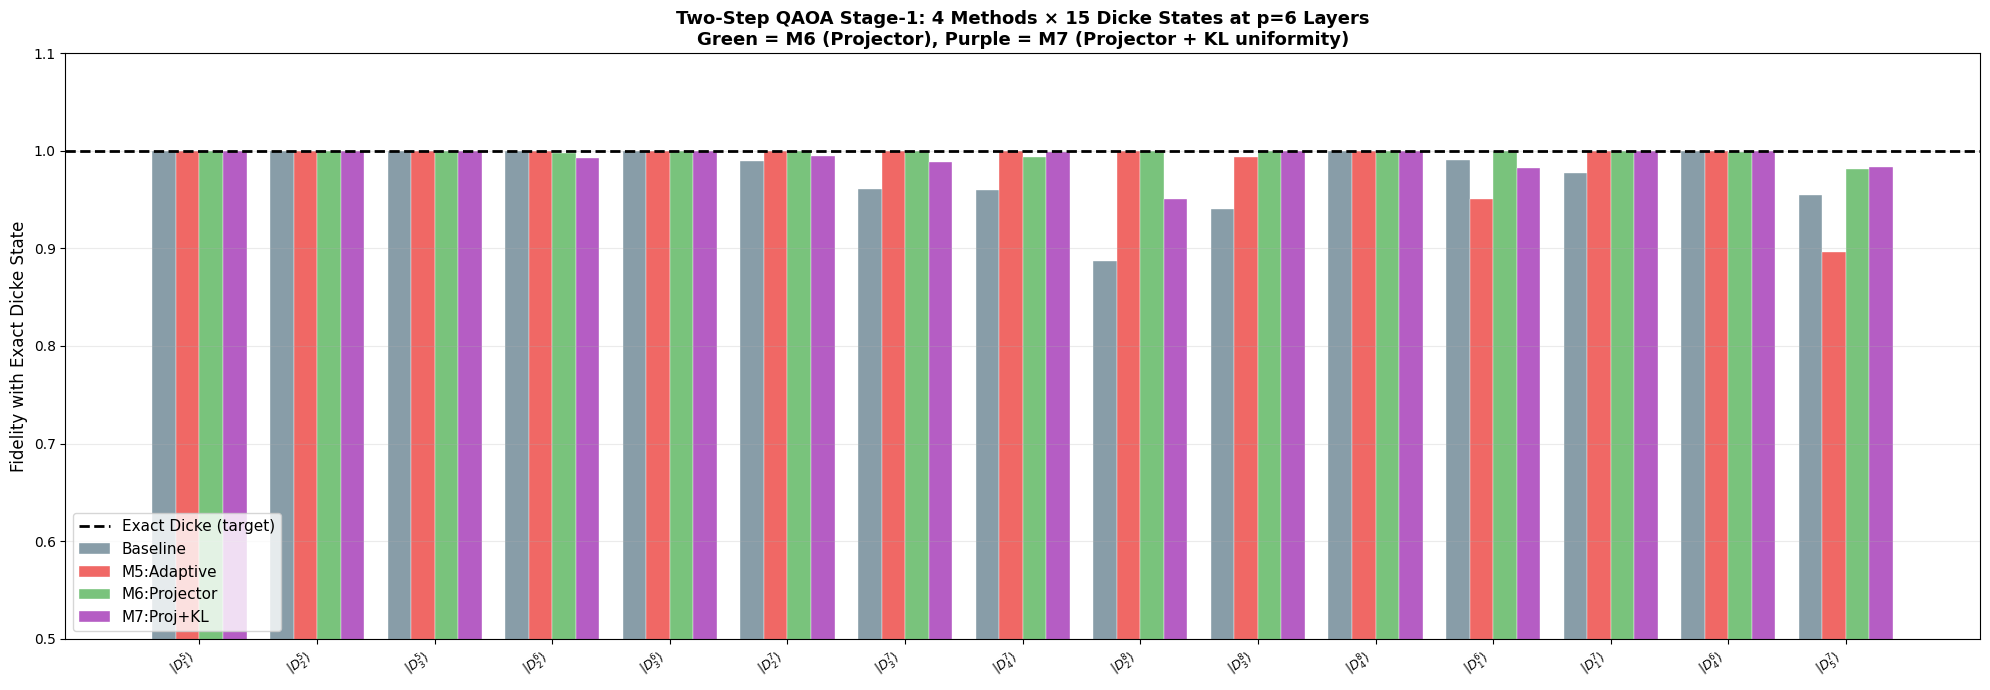

In [10]:
# ── Figure 1: Grouped bar chart ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 7))
x       = np.arange(len(BENCH_STATES))
width   = 0.2
colors  = {'Baseline':'#78909C', 'M5:Adaptive':'#EF5350',
           'M6:Projector':'#66BB6A', 'M7:Proj+KL':'#AB47BC'}
offsets = [-1.5, -0.5, 0.5, 1.5]

for method, off in zip(METHODS_ALL, offsets):
    vals = [fid_at_p6[(method, n, k)] for n, k in BENCH_STATES]
    ax.bar(x + off*width, vals, width, label=method,
           color=colors[method], alpha=0.88, edgecolor='white', linewidth=0.3)

ax.axhline(1.0, color='black', ls='--', lw=2, label='Exact Dicke (target)', zorder=5)
ax.set_xticks(x)
ax.set_xticklabels([f'$|D^{{{n}}}_{{{k}}}\\rangle$' for n, k in BENCH_STATES],
                   fontsize=9, rotation=35, ha='right')
ax.set_ylabel('Fidelity with Exact Dicke State', fontsize=12)
ax.set_title(f'Two-Step QAOA Stage-1: 4 Methods × 15 Dicke States at p={P_MAX} Layers\n'
             'Green = M6 (Projector), Purple = M7 (Projector + KL uniformity)',
             fontsize=13, fontweight='bold')
ax.set_ylim(0.5, 1.10)
ax.legend(fontsize=11, loc='lower left')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig('m6m7_benchmark_bar.png', dpi=140, bbox_inches='tight')
plt.show()

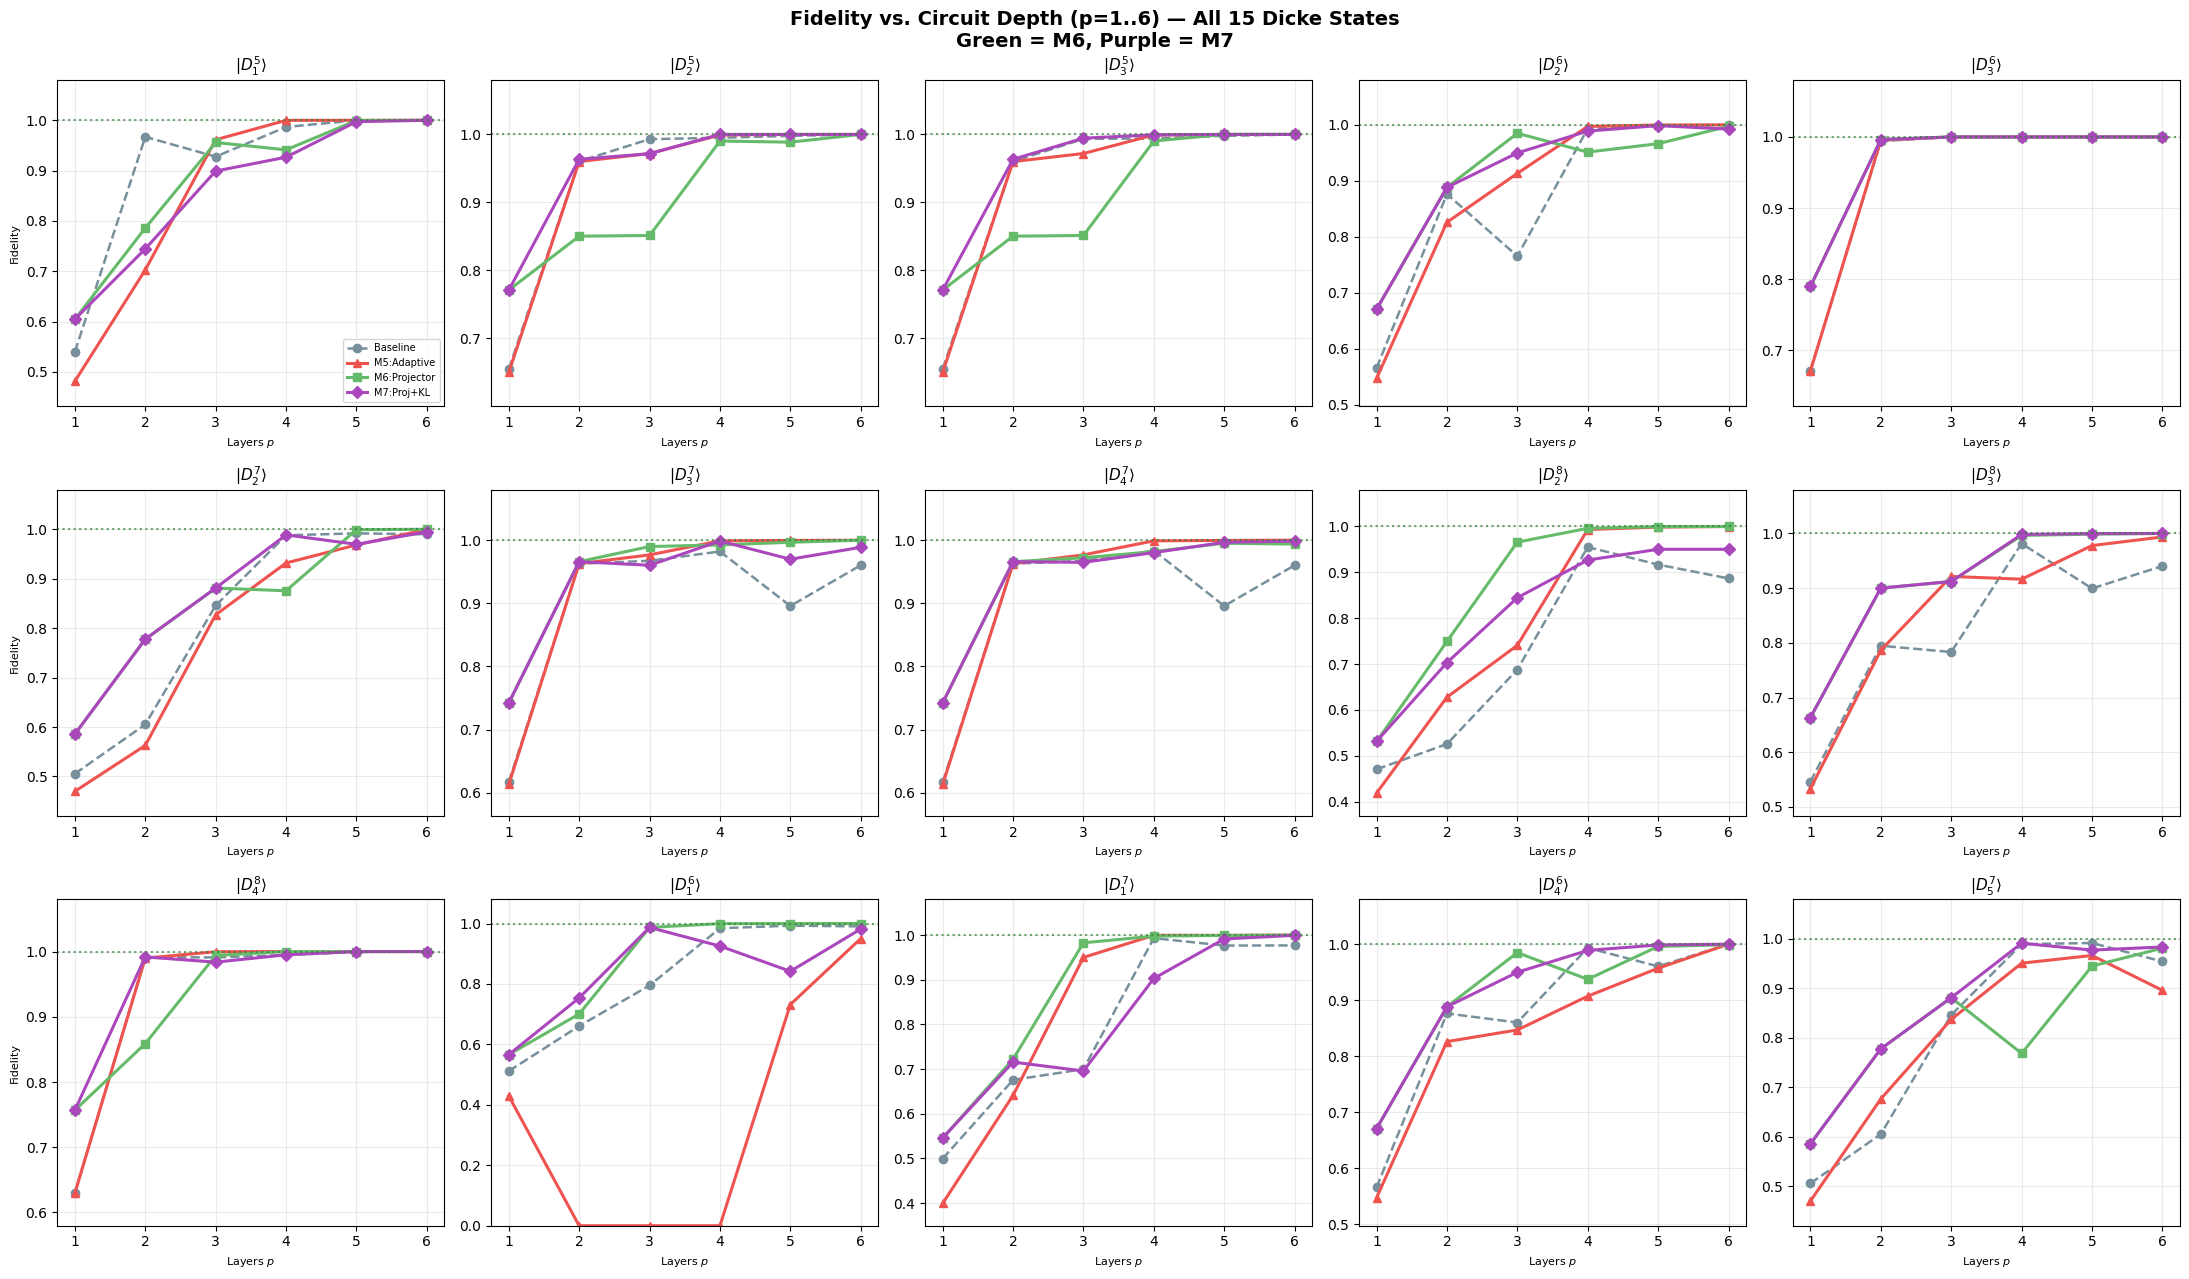

In [11]:
# ── Figure 2: Growth curves — 3×5 grid ────────────────────────────────────────
fig, axes = plt.subplots(3, 5, figsize=(22, 13), sharey=False)
ps = list(range(1, P_MAX + 1))

line_styles = {
    'Baseline':    ('o--', '#78909C', 1.8),
    'M5:Adaptive': ('^-',  '#EF5350', 2.2),
    'M6:Projector':('s-',  '#66BB6A', 2.2),
    'M7:Proj+KL':  ('D-',  '#AB47BC', 2.2),
}

for idx, (n, k) in enumerate(BENCH_STATES):
    ax = axes.flatten()[idx]
    for method, (fmt, col, lw) in line_styles.items():
        ax.plot(ps, fid_hist_all[method][(n,k)], fmt, color=col, lw=lw, ms=6, label=method)
    ax.axhline(1.0, color='#2e7d32', ls=':', lw=1.5, alpha=0.7)
    ax.set_title(f'$|D^{{{n}}}_{{{k}}}\\rangle$', fontsize=11, fontweight='bold')
    ax.set_xlabel('Layers $p$', fontsize=8)
    if idx % 5 == 0: ax.set_ylabel('Fidelity', fontsize=8)
    ax.set_xticks(ps)
    all_vals = [v for m in METHODS_ALL for v in fid_hist_all[m][(n,k)]]
    ax.set_ylim(max(0, min(all_vals) - 0.05), 1.08)
    ax.grid(True, alpha=0.25)
    if idx == 0: ax.legend(fontsize=7, loc='lower right')

fig.suptitle(f'Fidelity vs. Circuit Depth (p=1..{P_MAX}) — All 15 Dicke States\n'
             'Green = M6, Purple = M7', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('m6m7_growth_curves.png', dpi=130, bbox_inches='tight')
plt.show()

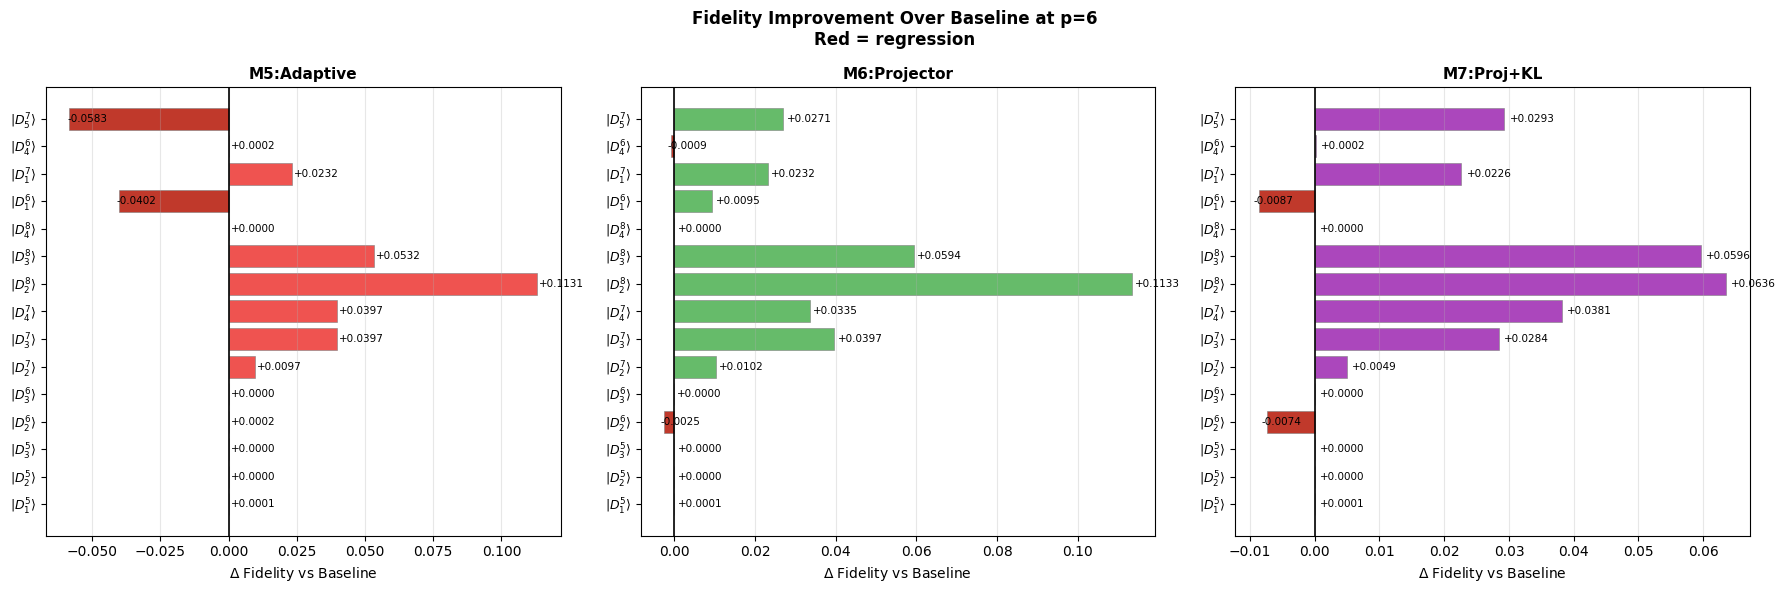

In [12]:
# ── Figure 3: Improvement over Baseline ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
improved_methods = ['M5:Adaptive', 'M6:Projector', 'M7:Proj+KL']
colors_imp       = ['#EF5350',      '#66BB6A',       '#AB47BC']
state_labels = [f'$|D^{{{n}}}_{{{k}}}\\rangle$' for n, k in BENCH_STATES]

for ax, method, col in zip(axes, improved_methods, colors_imp):
    gains    = [fid_at_p6[(method, n, k)] - fid_at_p6[('Baseline', n, k)]
                for n, k in BENCH_STATES]
    bar_clrs = ['#c0392b' if g < -1e-4 else col for g in gains]
    ax.barh(range(len(BENCH_STATES)), gains, color=bar_clrs,
            edgecolor='grey', linewidth=0.4)
    ax.axvline(0, color='black', linewidth=1.2)
    ax.set_yticks(range(len(BENCH_STATES)))
    ax.set_yticklabels(state_labels, fontsize=9)
    ax.set_xlabel(r'$\Delta$ Fidelity vs Baseline', fontsize=10)
    ax.set_title(method, fontsize=11, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    for i, g in enumerate(gains):
        ax.text(g + 0.0008 * np.sign(g), i, f'{g:+.4f}',
                va='center', fontsize=7.5)

fig.suptitle(f'Fidelity Improvement Over Baseline at p={P_MAX}\nRed = regression',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('m6m7_improvement.png', dpi=130, bbox_inches='tight')
plt.show()

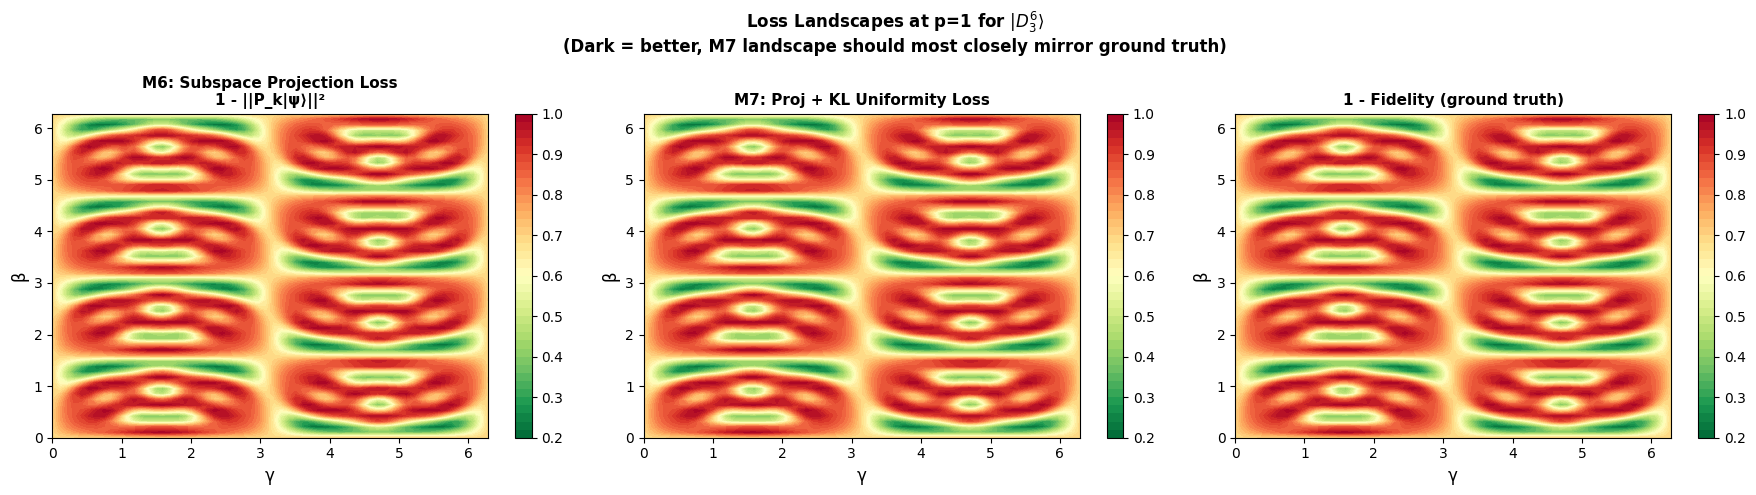

In [13]:
# ── Figure 4: Loss landscape comparison for a single state ─────────────────────
# Show the loss value (not fidelity) for M6 vs M7 at p=1 over a 2D grid
n_t, k_t = 6, 3   # balanced hard state
cd   = constraint_diag(n_t, k_t).astype(complex)
eig, evec = x_mixer_eig(n_t)
tgt  = exact_dicke(n_t, k_t)

G = np.linspace(0, 2*np.pi, 60)
B = np.linspace(0, 2*np.pi, 60)
GG, BB = np.meshgrid(G, B)

L6 = np.zeros_like(GG)
L7 = np.zeros_like(GG)
LF = np.zeros_like(GG)  # 1 - fidelity for comparison

for i in range(len(G)):
    for j in range(len(B)):
        params = np.array([G[i], B[j]])
        s = run_qaoa(n_t, cd, eig, evec, 1, params)
        L6[j, i] = subspace_projection_loss(s, n_t, k_t)
        L7[j, i] = subspace_uniformity_loss(s, n_t, k_t, beta=1.5)
        LF[j, i] = 1 - abs(s.conj() @ tgt)**2

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['M6: Subspace Projection Loss\n1 - ||P_k|ψ⟩||²',
          'M7: Proj + KL Uniformity Loss',
          '1 - Fidelity (ground truth)']
for ax, L, title in zip(axes, [L6, L7, LF], titles):
    im = ax.contourf(GG, BB, L, levels=40, cmap='RdYlGn_r')
    plt.colorbar(im, ax=ax)
    ax.set_xlabel('γ', fontsize=12); ax.set_ylabel('β', fontsize=12)
    ax.set_title(title, fontsize=11, fontweight='bold')

fig.suptitle(f'Loss Landscapes at p=1 for $|D^{{{n_t}}}_{{{k_t}}}\\rangle$\n'
             '(Dark = better, M7 landscape should most closely mirror ground truth)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('loss_landscape_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

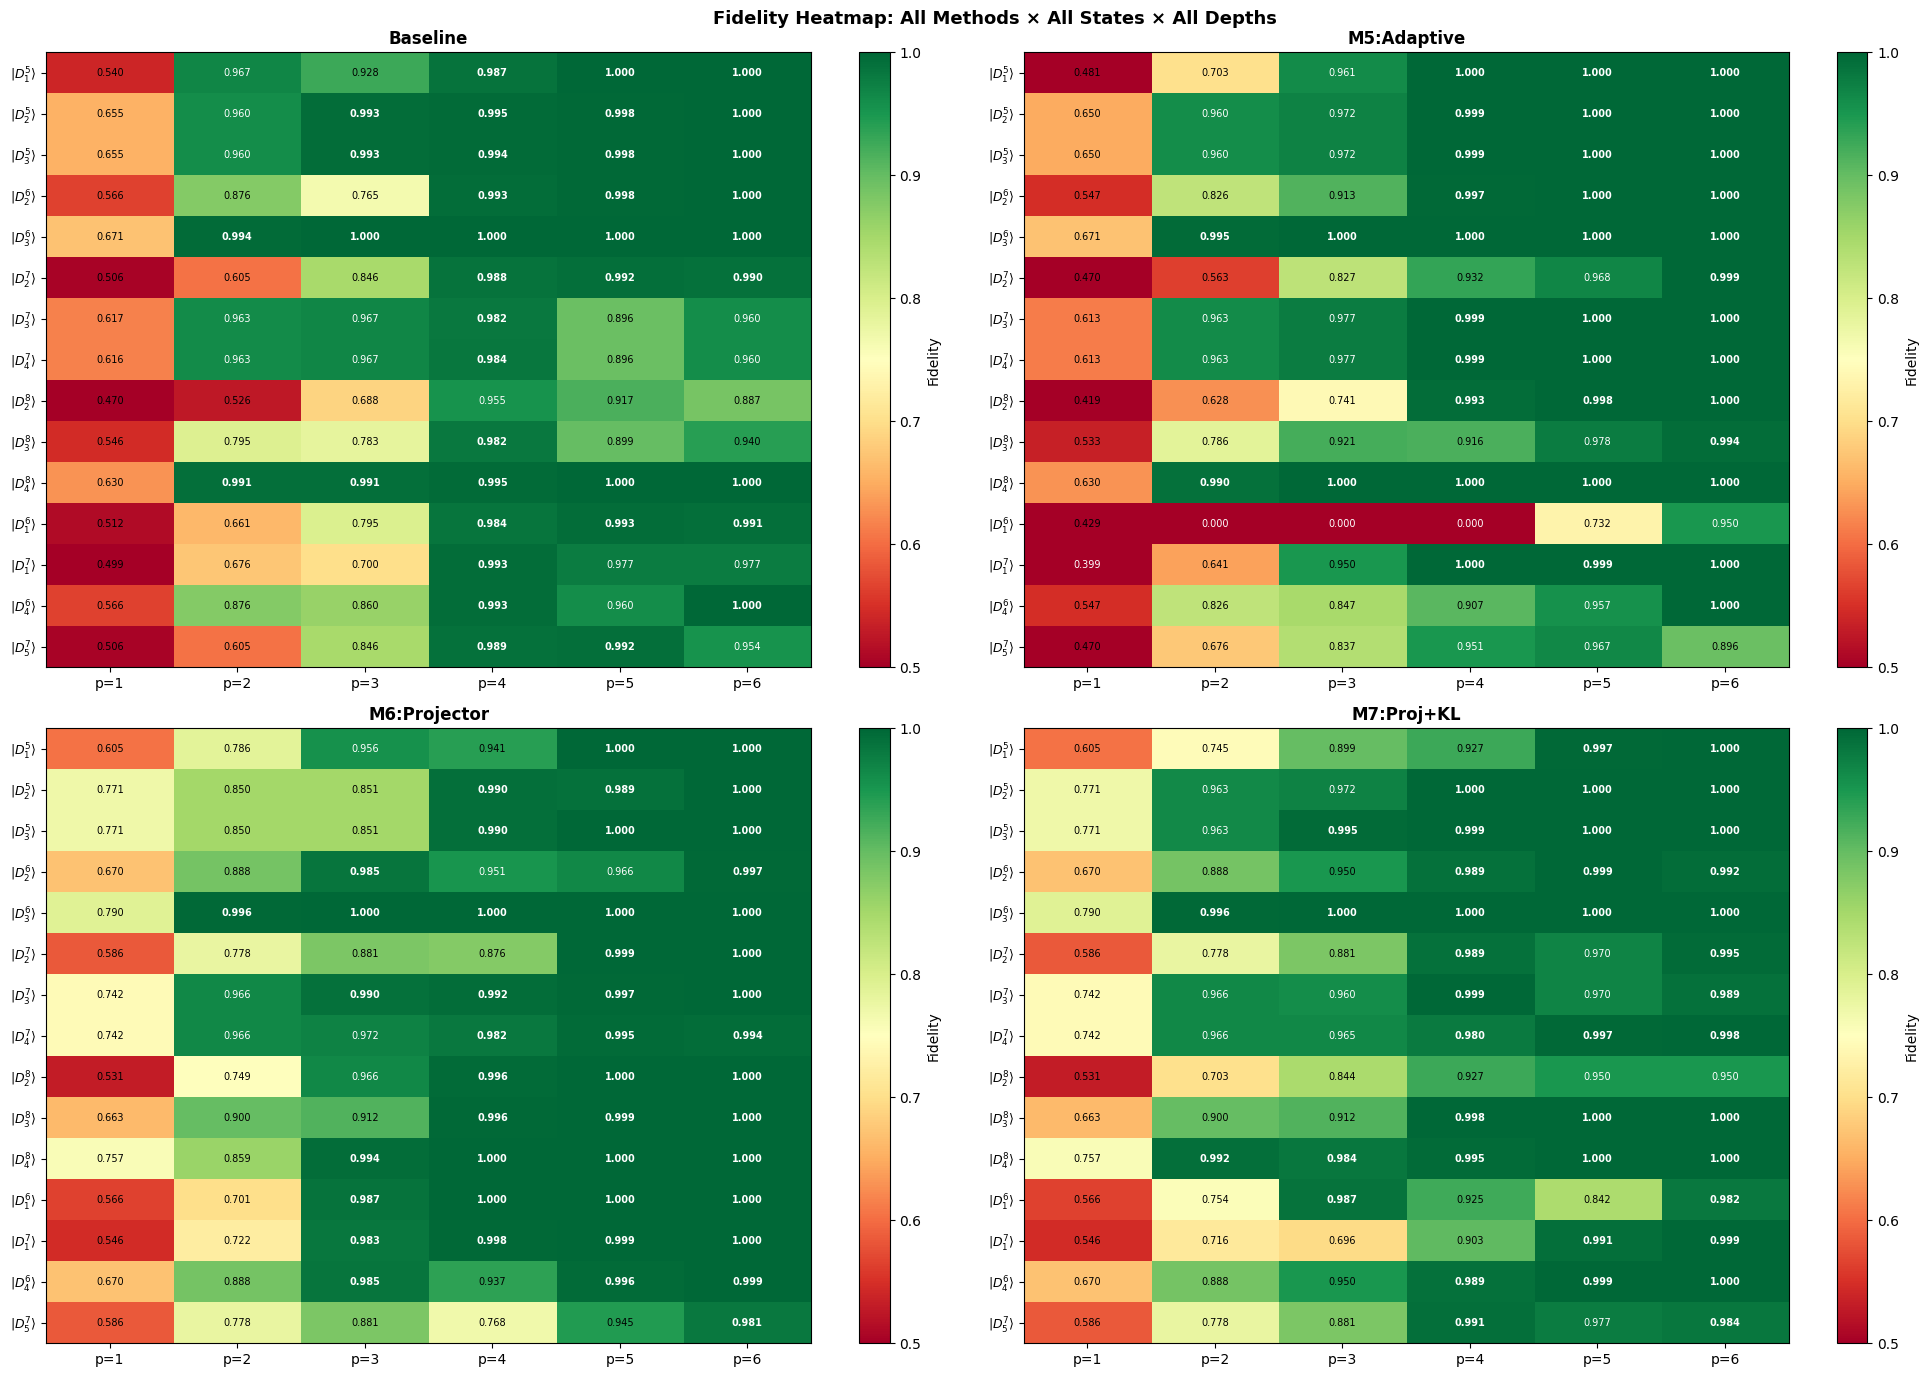

In [14]:
# ── Figure 5: Fidelity heatmap ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

for method, ax in zip(METHODS_ALL, axes.flatten()):
    data = np.zeros((len(BENCH_STATES), P_MAX))
    for si, (n, k) in enumerate(BENCH_STATES):
        for pi in range(P_MAX):
            data[si, pi] = fid_hist_all[method][(n,k)][pi]
    im = ax.imshow(data, aspect='auto', cmap='RdYlGn', vmin=0.5, vmax=1.0)
    ax.set_xticks(range(P_MAX))
    ax.set_xticklabels([f'p={p}' for p in range(1, P_MAX+1)], fontsize=10)
    ax.set_yticks(range(len(BENCH_STATES)))
    ax.set_yticklabels([f'$|D^{{{n}}}_{{{k}}}\\rangle$' for n,k in BENCH_STATES], fontsize=9)
    ax.set_title(method, fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Fidelity')
    for si in range(len(BENCH_STATES)):
        for pi in range(P_MAX):
            v = data[si, pi]
            ax.text(pi, si, f'{v:.3f}', ha='center', va='center', fontsize=7,
                    color='black' if 0.4 < v < 0.95 else 'white',
                    fontweight='bold' if v > 0.98 else 'normal')

fig.suptitle('Fidelity Heatmap: All Methods × All States × All Depths',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('m6m7_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()

## Analysis: Why M6/M7 Should Outperform M5

### Root Cause of M5's Limitation

M5 optimizes:
$$\mathcal{L}_{M5} = \langle(\hat{N}-k)^2\rangle + \alpha(p)\cdot\text{Var}(\hat{N})$$

This is a **necessary** condition for a Dicke state (both terms = 0) but **not sufficient**.
Consider the state $|\psi\rangle = |x_0\rangle$ (a single k-hot bitstring):  
- $\langle(\hat{N}-k)^2\rangle = 0$ ✓  
- $\text{Var}(\hat{N}) = 0$ ✓  
- Fidelity with Dicke = $1/C(n,k)$ ✗ (tiny!)

### M6 Fix

M6 optimizes $\mathcal{L}_{M6} = 1 - \|P_k|\psi\rangle\|^2$, where $P_k$ is the projector onto the full k-hot subspace.
- Any state in the k-hot subspace (not just single bitstrings) achieves $\mathcal{L}_{M6} = 0$
- The landscape is **smoother**: it's a sum of squared amplitudes, differentiable everywhere
- No hyperparameter $\alpha$ to tune

### M7 Fix

M7 adds the KL term to enforce uniformity within the subspace:
$$\mathcal{L}_{M7} = \mathcal{L}_{M6} + \beta \cdot \text{KL}(q\|\text{Uniform})$$

The combined loss has its **unique global minimum at the exact Dicke state** (within the expressibility of the QAOA circuit). The KL term directly penalizes non-uniformity — the only degree of freedom remaining once the subspace projection loss is zero.

### Summary Table

| Loss | Zero at single k-hot bitstring? | Zero at exact Dicke? | Unique min = Dicke? |
|------|-------------------------------|----------------------|---------------------|
| $\langle(\hat{N}-k)^2\rangle$ | Yes | Yes | **No** |
| $+ \alpha\cdot\text{Var}(\hat{N})$ | Yes | Yes | **No** |
| M6: $1 - \|P_k|\psi\rangle\|^2$ | Yes | Yes | **No** |
| M7: M6 + KL | **No** | Yes | **Yes** |
